In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [19]:
df = pd.read_csv("synthetic_project_cost_dataset_realistic.csv")

df.head()
df.shape

(5000, 7)

In [20]:
X = df.drop("final_billed_amount", axis=1)
y = df["final_billed_amount"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
categorical_cols = ["project_type", "client_industry"]
numeric_cols = [
    "estimated_timeline_months",
    "team_allocation",
    "complexity_score",
    "revision_count",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [28]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['project_type',
                                                   'client_industry']),
                                                 ('num', 'passthrough',
                                                  ['estimated_timeline_months',
                                                   'team_allocation',
                                                   'complexity_score',
                                                   'revision_count'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [29]:
y_pred = pipeline.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 741577.5815957608
RMSE: 1375934.4408144876
R2 Score: 0.9241427632053281


In [31]:
print("Mean Cost:", y.mean())

Mean Cost: 6362431.099182


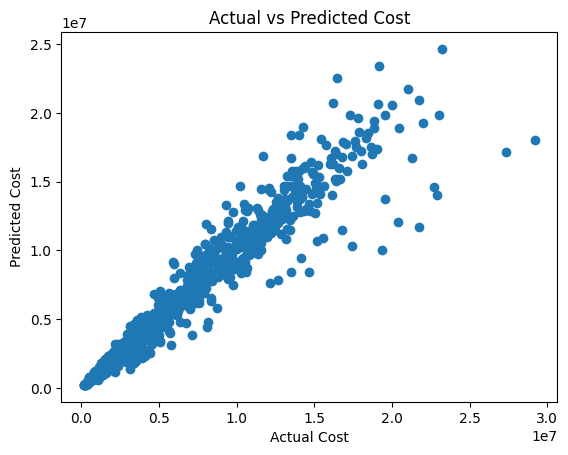

In [32]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cost")
plt.show()

In [42]:
# Get model
rf_model = pipeline.named_steps["model"]

# Get feature names after encoding
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(["project_type", "client_industry"])

all_features = list(encoded_cat_features) + [
    "estimated_timeline_months",
    "team_allocation",
    "complexity_score",
    "revision_count",
]

# Get importance values
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
20,estimated_timeline_months,0.447636
21,team_allocation,0.441997
22,complexity_score,0.037891
23,revision_count,0.015144
16,client_industry_Finance,0.010058
1,project_type_Blockchain Solution,0.008306
0,project_type_AI/ML Solution,0.004827
19,client_industry_Startup,0.004542
17,client_industry_Healthcare,0.004337
15,client_industry_Education,0.002616


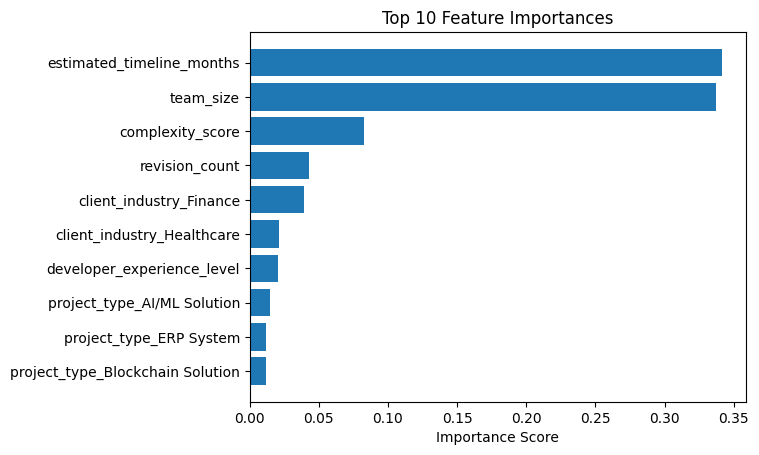

In [34]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_r2 = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
cv_mae = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_absolute_error')

print("Cross Validation R2 Scores:", cv_r2)
print("Average CV R2:", np.mean(cv_r2))

print("\nCross Validation MAE:", -cv_mae)
print("Average CV MAE:", -np.mean(cv_mae))

Cross Validation R2 Scores: [0.92651865 0.93717336 0.89987248 0.90540273 0.94121171]
Average CV R2: 0.9220357855681787

Cross Validation MAE: [733938.39474323 738365.68196289 854618.99903955 801972.84369988
 716323.28893559]
Average CV MAE: 769043.8416762296


In [44]:
train_r2 = pipeline.score(X_train, y_train)
test_r2 = pipeline.score(X_test, y_test)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9895287173434566
Test R2: 0.9241427632053281


In [45]:
import joblib
joblib.dump(pipeline, "cost_prediction_model.pkl")

['cost_prediction_model.pkl']

In [ ]:
import pandas as pd

new_project = pd.DataFrame({
    "project_type": ["AI/ML Solution"],
    "client_industry": ["E-commerce"],
    "estimated_timeline_months": [5],
    "team_allocation": [6],
    "complexity_score": [3],
    "revision_count": [3]
})

predicted_cost = pipeline.predict(new_project)

print("Predicted Project Cost:", round(predicted_cost[0], 2))

Predicted Project Cost: 2193431.72
